In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision.models import resnet18
from transformers import ViTForImageClassification, ViTImageProcessor
import numpy as np
from torch.utils.data import Subset

# Transformations to be applied to the images
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to the input size required by ViT and ResNet
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # Normalize for CIFAR-10
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CIFAR-10 dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

subset_size = 1000  # Choose the desired size of your subset
train_indices = np.random.choice(len(trainset), subset_size, replace=False)   #took only 1000 images from cifar10
test_indices = np.random.choice(len(testset), subset_size, replace=False)  #should've chaneg the subset_size here for test to around 200 instead of keeping it 1000

train_subset = Subset(trainset, train_indices)
test_subset = Subset(testset, test_indices)

trainloader = torch.utils.data.DataLoader(train_subset, batch_size=16, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(test_subset, batch_size=16, shuffle=False, num_workers=2)

cnn_model = resnet18(weights='DEFAULT').to(device)
cnn_model.fc = nn.Linear(cnn_model.fc.in_features, 10).to(device)
cnn_model.to(device)

vit_image_processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
vit_model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224', num_labels=10, ignore_mismatched_sizes=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)
optimizer_vit = optim.Adam(vit_model.parameters(), lr=0.001)

def train_model(model, trainloader, optimizer, criterion, num_epochs=5):
    model.train()
    losses = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            if isinstance(model, ViTForImageClassification):
                loss = criterion(outputs.logits, labels)
            else:
                loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        losses.append(running_loss/len(trainloader))
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}")
        torch.cuda.empty_cache()

train_model(cnn_model, trainloader, optimizer_cnn, criterion)
train_model(vit_model, trainloader, optimizer_vit, criterion)

Files already downloaded and verified
Files already downloaded and verified


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1, Loss: 1.7374415378721932
Epoch 2, Loss: 1.176095235915411
Epoch 3, Loss: 0.9022465797643813
Epoch 4, Loss: 0.7643033644509694
Epoch 5, Loss: 0.5184044776454805
Epoch 1, Loss: 2.313375022676256
Epoch 2, Loss: 2.1302706362709167
Epoch 3, Loss: 2.006587166634817
Epoch 4, Loss: 1.9338889481529358
Epoch 5, Loss: 1.914991091168116


In [ ]:
def evaluate_model(model, testloader):
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for inputs, labels in testloader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      if hasattr(outputs, 'logits'):
          _, predicted = torch.max(outputs.logits, 1)
      else:
          _, predicted = torch.max(outputs, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  accuracy = 100 * correct / total
  return accuracy

cnn_accuracy = evaluate_model(cnn_model, testloader)
vit_accuracy = evaluate_model(vit_model, testloader)

print(f"CNN Accuracy: {cnn_accuracy}%")
print(f"ViT Accuracy: {vit_accuracy}%")

CNN Accuracy: 53.2%
ViT Accuracy: 24.2%


got less accuracy as i trained the vit, cnn models on already pre-trained on imagenet datasets but with different mean and sd should not train in case i should use the same values as
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to the input size required by ViT and ResNet
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Use ImageNet normalization
])


In [ ]:
transform_fashion = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # Normalize for FashionMNIST (single channel)
])

In [ ]:
from torchvision.datasets import CIFAR100

# Load Fashion MNIST dataset
cifar100_train = CIFAR100(root='./data', train=True, download=True, transform=transform)
cifar100_test = CIFAR100(root='./data', train=False, download=True, transform=transform)

# Define the Transportation class indices in CIFAR-100
transportation_classes = [0, 1, 2, 3, 4]  # Bicycle, Bus, Motorcycle, Scooter, Train

# Get indices for Transportation classes
train_indices = [i for i, (_, label) in enumerate(cifar100_train) if label in transportation_classes]
test_indices = [i for i, (_, label) in enumerate(cifar100_test) if label in transportation_classes]

# Shuffle and select 100 indices for training
np.random.shuffle(train_indices)
cifar100_train_subset_indices = train_indices[:100]

# Shuffle and select 20 indices for testing
np.random.shuffle(test_indices)
cifar100_test_subset_indices = test_indices[:20]

cifar100_train_subset = Subset(cifar100_train, cifar100_train_subset_indices)
cifar100_test_subset = Subset(cifar100_test, cifar100_test_subset_indices)

cifar100_trainloader = torch.utils.data.DataLoader(cifar100_train_subset, batch_size=16, shuffle=True, num_workers=2)
cifar100_testloader = torch.utils.data.DataLoader(cifar100_test_subset, batch_size=16, shuffle=False, num_workers=2)



Files already downloaded and verified
Files already downloaded and verified


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

In [ ]:
train_model(cnn_model, cifar100_trainloader, optimizer_cnn, criterion, num_epochs=3)
train_model(vit_model, cifar100_trainloader, optimizer_vit, criterion, num_epochs=3)

Epoch 1, Loss: 3.579171589442662
Epoch 2, Loss: 1.3432062864303589
Epoch 3, Loss: 0.6680088937282562
Epoch 1, Loss: 2.2835207666669572
Epoch 2, Loss: 1.755666630608695
Epoch 3, Loss: 1.436761004584176


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
!pip install seaborn scikit-learn


Evaluating CNN Model:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.4083333333333333
Recall: 0.6
F1 Score: 0.4766666666666667
Confusion Matrix:
[[3 0 1 0 0]
 [0 4 0 0 0]
 [0 0 5 0 0]
 [1 1 3 0 0]
 [0 1 1 0 0]]


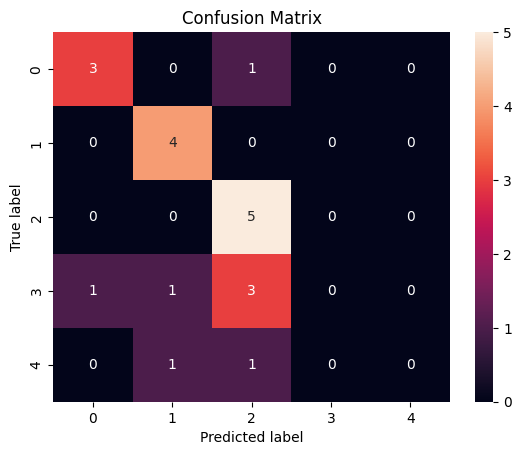

Evaluating ViT Model:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.3555555555555555
Recall: 0.4
F1 Score: 0.35809523809523813
Confusion Matrix:
[[3 1 0 0 0]
 [1 2 1 0 0]
 [2 1 2 0 0]
 [0 0 5 0 0]
 [0 0 1 0 1]]


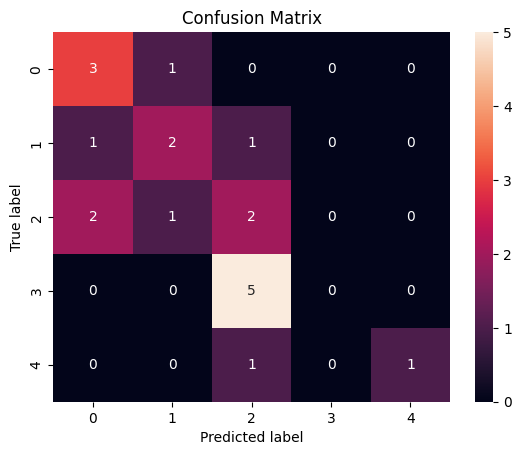

In [ ]:
def evaluate_fine_tune_model(model, testloader):
  model.eval()
  all_preds = []
  all_labels = []
  with torch.no_grad():
    for inputs, labels in testloader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      if hasattr(outputs, 'logits'):
          _, predicted = torch.max(outputs.logits, 1)
      else:
          _, predicted = torch.max(outputs, 1)
      all_preds.extend(predicted.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

      #calculate metrics
      precision = precision_score(all_labels, all_preds, average='weighted')
      recall = recall_score(all_labels, all_preds, average='weighted')
      f1 = f1_score(all_labels, all_preds, average='weighted')
      conf_matrix = confusion_matrix(all_labels, all_preds)
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"F1 Score: {f1}")
  # Calculate confusion matrix
  cm = confusion_matrix(all_labels, all_preds)
  print("Confusion Matrix:")
  print(cm)

  # Display confusion matrix using seaborn
  sns.heatmap(cm, annot=True, fmt='d')
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.title('Confusion Matrix')
  plt.show()
print("Evaluating CNN Model:")
evaluate_fine_tune_model(cnn_model, cifar100_testloader)

print("Evaluating ViT Model:")
evaluate_fine_tune_model(vit_model, cifar100_testloader)
